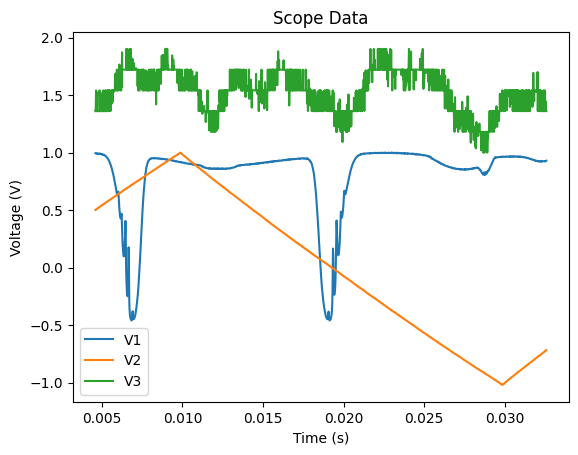

In [63]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt



data = pd.read_csv("scope_7.csv")
data["V2"] = data["V2"]/data["V2"].max()
data["V3"] = data["V3"]/data["V3"].max()
data["V1"] = data["V1"]/data["V1"].max()

plt.plot(data["T"], data["V1"], label="V1")
plt.plot(data["T"], data["V2"], label="V2")

plt.plot(data["T"], data["V3"], label="V3")
# plt.plot(data["T"], data["V4"], label="V4")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Scope Data")
plt.legend()
plt.show()


Fabry-Perot пики
965     0.016110
1618    0.025252
Name: T_shift, dtype: float64

GHz per T
437541.0194705755

Пики насыщенного
1033    0.019662
1053    0.019942
1069    0.020166
1088    0.020432
1103    0.020642
Name: T_shift, dtype: float64

Расстояния MHz
[122.51148545  98.00918836 116.38591118  91.88361409]
Растония между уровнями
220.5206738131705 208.26952526799425


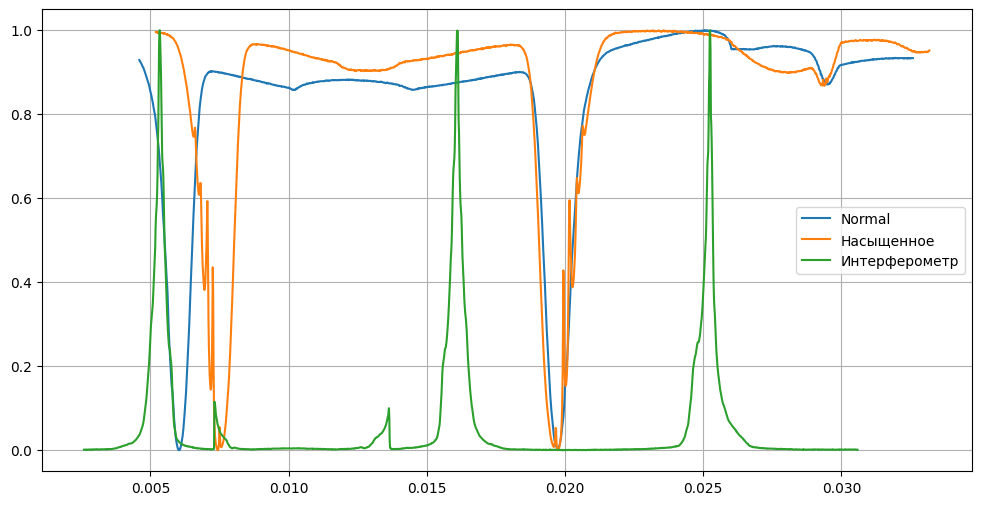

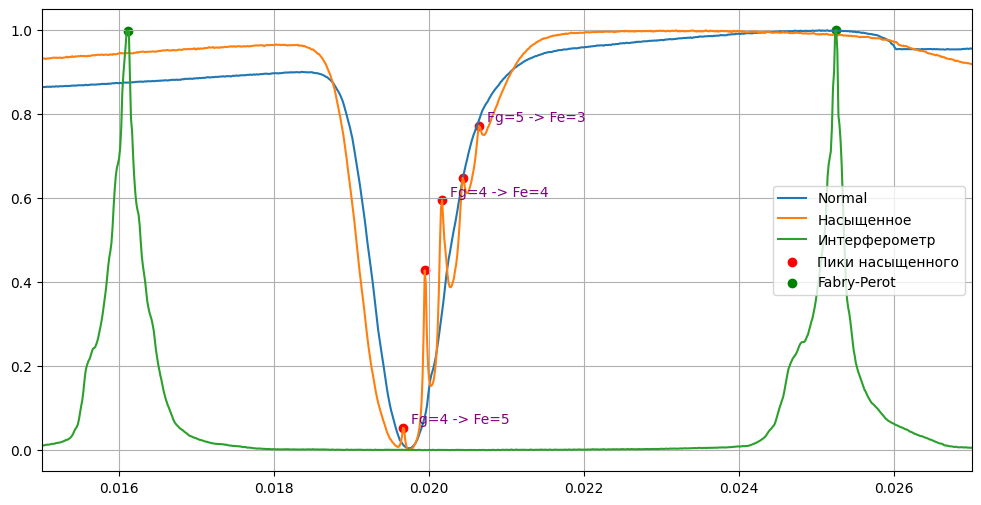

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# =========================
# Загрузка
# =========================

data_norm = pd.read_csv("scope_8.csv")
data_nas = pd.read_csv("scope_7.csv")
data_febri = pd.read_csv("scope_10.csv")

# =========================
# СДВИГИ
# =========================

shift_norm = 0.0
shift_nas = 0.0006
shift_febri = -0.002

data_norm["T_shift"] = data_norm["T"] + shift_norm
data_nas["T_shift"] = data_nas["T"] + shift_nas
data_febri["T_shift"] = data_febri["T"] + shift_febri





# =========================
# НОРМИРОВКА
# =========================


data_norm["V_norm"] = (data_norm["V1"] - data_norm["V1"].min()) / (data_norm["V1"].max() - data_norm["V1"].min())
data_nas["V_norm"] = (data_nas["V1"] - data_nas["V1"].min()) / (data_nas["V1"].max() - data_nas["V1"].min())
data_febri["V_norm"] = (data_febri["V3"] - data_febri["V3"].min()) / (data_febri["V3"].max() - data_febri["V3"].min())

# =========================
# ОБЩИЙ СРЕЗ
# =========================

T_min = 0.015
T_max = 0.027


# УЗКИЙ СРЕЗ ДЛЯ НАСЫЩЕННОГО
T_nas_min = 0.017
T_nas_max = 0.025

data_norm_cut = data_norm[(data_norm["T_shift"] > T_min) & (data_norm["T_shift"] < T_max)]
data_nas_cut = data_nas[(data_nas["T_shift"] > T_nas_min) & (data_nas["T_shift"] < T_nas_max)]
data_febri_cut = data_febri[(data_febri["T_shift"] > T_min) & (data_febri["T_shift"] < T_max)]

# =========================
# FABRY PEROT
# =========================

peaks_febri, props = find_peaks(
    data_febri_cut["V_norm"],
    prominence=0.1,
    distance=200
)

# два самых больших
top2 = np.argsort(props["prominences"])[-2:]
peaks_febri = peaks_febri[top2]

febri_peaks = data_febri_cut.iloc[peaks_febri]
febri_peaks = febri_peaks.sort_values("T_shift")

GHz_per_T = 4000 / (febri_peaks["T_shift"].iloc[1] - febri_peaks["T_shift"].iloc[0])

print("Fabry-Perot пики")
print(febri_peaks["T_shift"])

print("\nGHz per T")
print(GHz_per_T)

# =========================
# НАСЫЩЕННОЕ ПОГЛОЩЕНИЕ
# =========================


data_nas_peaks = data_nas[
    (data_nas["T_shift"] > T_nas_min) &
    (data_nas["T_shift"] < T_nas_max)
]


peaks_nas, props_nas = find_peaks(
    data_nas_cut["V_norm"],
    prominence=0.02,
    distance=6
)

nas_peaks = data_nas_cut.iloc[peaks_nas]

distances_T = np.diff(nas_peaks["T_shift"])
distances_GHz = distances_T * GHz_per_T

print("\nПики насыщенного")
print(nas_peaks["T_shift"])

print("\nРасстояния MHz")
print(distances_GHz)
print("Растония между уровнями")
print(distances_GHz[0] + distances_GHz[1], distances_GHz[2]+distances_GHz[3])
# =========================
# ОСНОВНОЙ ГРАФИК
# =========================

plt.figure(figsize=(12,6))

plt.plot(data_norm["T_shift"], data_norm["V_norm"], label="Normal")
plt.plot(data_nas["T_shift"], data_nas["V_norm"], label="Насыщенное")
plt.plot(data_febri["T_shift"], data_febri["V_norm"], label="Интерферометр")

plt.legend()
plt.grid()

# =========================
# ZOOM ГРАФИК
# =========================

plt.figure(figsize=(12,6))

plt.plot(data_norm["T_shift"], data_norm["V_norm"], label="Normal")
plt.plot(data_nas["T_shift"], data_nas["V_norm"], label="Насыщенное")
plt.plot(data_febri["T_shift"], data_febri["V_norm"], label="Интерферометр")

# все пики на zoom
plt.scatter(
    nas_peaks["T_shift"],
    nas_peaks["V_norm"],
    color="red",
    label="Пики насыщенного"
)
labels = ['Fg=4 -> Fe=5', 'Fg=4 -> Fe=4', 'Fg=5 -> Fe=3']
for i, idx in enumerate([0, 2, 4]):
    plt.annotate(labels[i], xy=(nas_peaks.iloc[idx]["T_shift"], nas_peaks.iloc[idx]["V_norm"]), 
                 xytext=(nas_peaks.iloc[idx]["T_shift"] + 0.0001, nas_peaks.iloc[idx]["V_norm"] + 0.01),
                 fontsize=10, color='Purple')

plt.scatter(
    febri_peaks["T_shift"],
    febri_peaks["V_norm"],
    color="green",
    label="Fabry-Perot"
)   

plt.xlim(0.015, 0.027)

plt.legend()
plt.grid()
plt.savefig("cooling_cs.png", dpi=300)
plt.show()

Fabry-Perot пики
965     0.016110
1618    0.025252
Name: T_shift, dtype: float64

MHz per T
328155.7646029316

Пики насыщенного
1034    0.019676
1053    0.019942
1068    0.020152
1088    0.020432
1103    0.020642
1188    0.021832
Name: T_shift, dtype: float64

Расстояния MHz
[ 87.28943338  68.91271057  91.88361409  68.91271057 390.50535988]

Расстояния между уровнями
156.2021439509957 160.79632465543676


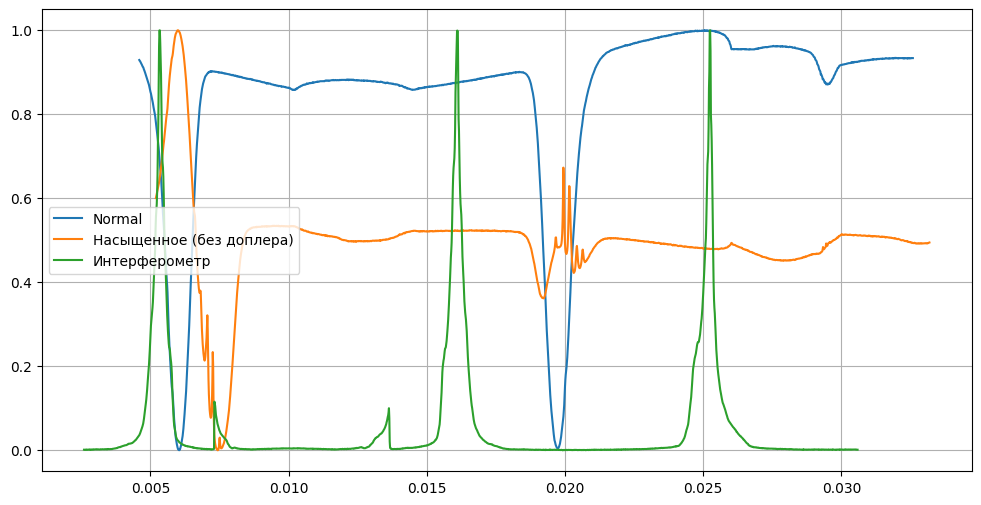

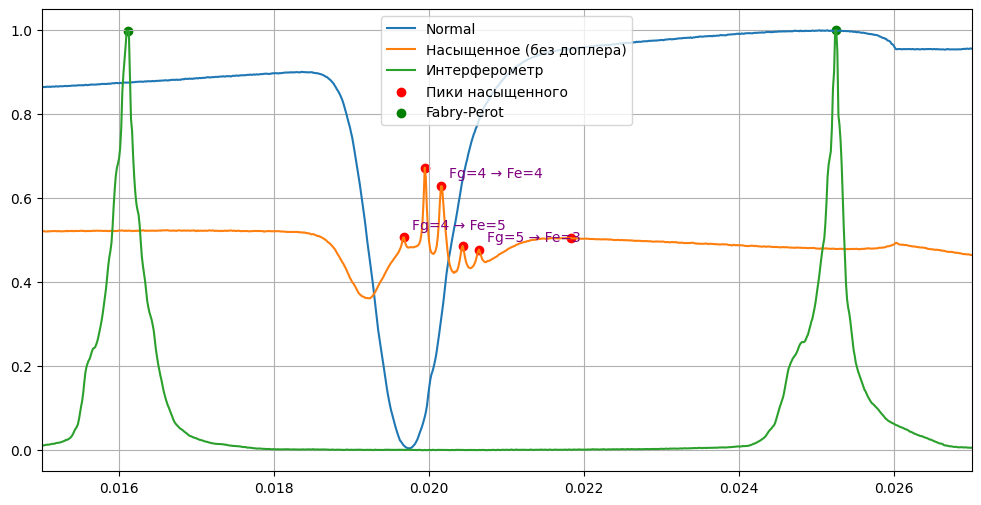

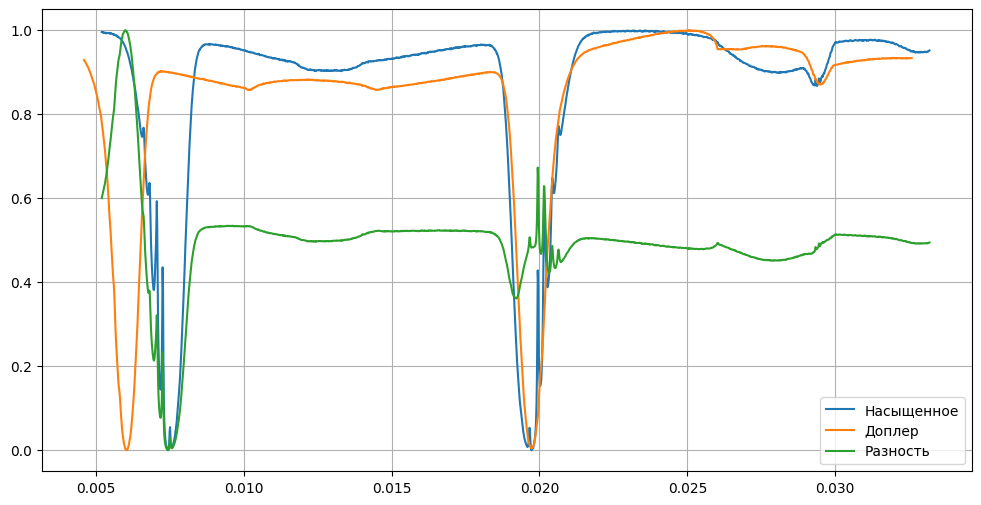

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# =========================
# Загрузка
# =========================

data_norm = pd.read_csv("scope_8.csv")
data_nas = pd.read_csv("scope_7.csv")
data_febri = pd.read_csv("scope_10.csv")

# =========================
# СДВИГИ
# =========================

shift_norm = 0.0
shift_nas = 0.0006
shift_febri = -0.002

data_norm["T_shift"] = data_norm["T"] + shift_norm
data_nas["T_shift"] = data_nas["T"] + shift_nas
data_febri["T_shift"] = data_febri["T"] + shift_febri

# =========================
# НОРМИРОВКА
# =========================

data_norm["V_norm"] = (
    (data_norm["V1"] - data_norm["V1"].min()) /
    (data_norm["V1"].max() - data_norm["V1"].min())
)

data_nas["V_norm"] = (
    (data_nas["V1"] - data_nas["V1"].min()) /
    (data_nas["V1"].max() - data_nas["V1"].min())
)

data_febri["V_norm"] = (
    (data_febri["V3"] - data_febri["V3"].min()) /
    (data_febri["V3"].max() - data_febri["V3"].min())
)

# =========================
# ВЫЧИТАНИЕ ДОПЛЕРОВСКОГО ФОНА
# =========================

norm_interp = np.interp(
    data_nas["T_shift"],
    data_norm["T_shift"],
    data_norm["V_norm"]
)

data_nas["V_sub"] = data_nas["V_norm"] - norm_interp

# нормировка после вычитания
data_nas["V_sub"] = data_nas["V_sub"] - data_nas["V_sub"].min()
data_nas["V_sub"] = data_nas["V_sub"] / data_nas["V_sub"].max()

# =========================
# ДИАПАЗОНЫ
# =========================

T_min = 0.015
T_max = 0.027

T_nas_min = 0.017
T_nas_max = 0.025

data_norm_cut = data_norm[
    (data_norm["T_shift"] > T_min) &
    (data_norm["T_shift"] < T_max)
]

data_nas_cut = data_nas[
    (data_nas["T_shift"] > T_nas_min) &
    (data_nas["T_shift"] < T_nas_max)
]

data_febri_cut = data_febri[
    (data_febri["T_shift"] > T_min) &
    (data_febri["T_shift"] < T_max)
]

# =========================
# FABRY-PEROT
# =========================

peaks_febri, props = find_peaks(
    data_febri_cut["V_norm"],
    prominence=0.1,
    distance=200
)

top2 = np.argsort(props["prominences"])[-2:]
peaks_febri = peaks_febri[top2]

febri_peaks = data_febri_cut.iloc[peaks_febri]
febri_peaks = febri_peaks.sort_values("T_shift")

GHz_per_T = 3000 / (
    febri_peaks["T_shift"].iloc[1] -
    febri_peaks["T_shift"].iloc[0]
)

print("Fabry-Perot пики")
print(febri_peaks["T_shift"])

print("\nMHz per T")
print(GHz_per_T)

# =========================
# НАСЫЩЕННОЕ ПОГЛОЩЕНИЕ
# =========================

peaks_nas, props_nas = find_peaks(
    data_nas_cut["V_sub"],
    prominence=0.02,
    distance=6
)

nas_peaks = data_nas_cut.iloc[peaks_nas]

distances_T = np.diff(nas_peaks["T_shift"])
distances_MHz = distances_T * GHz_per_T

print("\nПики насыщенного")
print(nas_peaks["T_shift"])

print("\nРасстояния MHz")
print(distances_MHz)

print("\nРасстояния между уровнями")
print(
    distances_MHz[0] + distances_MHz[1],
    distances_MHz[2] + distances_MHz[3]
)

# =========================
# ОСНОВНОЙ ГРАФИК
# =========================

plt.figure(figsize=(12,6))

plt.plot(
    data_norm["T_shift"],
    data_norm["V_norm"],
    label="Normal"
)

plt.plot(
    data_nas["T_shift"],
    data_nas["V_sub"],
    label="Насыщенное (без доплера)"
)

plt.plot(
    data_febri["T_shift"],
    data_febri["V_norm"],
    label="Интерферометр"
)

plt.legend()
plt.grid()

# =========================
# ZOOM ГРАФИК
# =========================

plt.figure(figsize=(12,6))

plt.plot(
    data_norm["T_shift"],
    data_norm["V_norm"],
    label="Normal"
)

plt.plot(
    data_nas["T_shift"],
    data_nas["V_sub"],
    label="Насыщенное (без доплера)"
)

plt.plot(
    data_febri["T_shift"],
    data_febri["V_norm"],
    label="Интерферометр"
)

# пики насыщенного
plt.scatter(
    nas_peaks["T_shift"],
    nas_peaks["V_sub"],
    color="red",
    label="Пики насыщенного"
)

# подписи переходов
labels = [
    'Fg=4 → Fe=5',
    'Fg=4 → Fe=4',
    'Fg=5 → Fe=3'
]

for i, idx in enumerate([0, 2, 4]):
    plt.annotate(
        labels[i],
        xy=(
            nas_peaks.iloc[idx]["T_shift"],
            nas_peaks.iloc[idx]["V_sub"]
        ),
        xytext=(
            nas_peaks.iloc[idx]["T_shift"] + 0.0001,
            nas_peaks.iloc[idx]["V_sub"] + 0.02
        ),
        fontsize=10,
        color='purple'
    )

# пики Fabry-Perot
plt.scatter(
    febri_peaks["T_shift"],
    febri_peaks["V_norm"],
    color="green",
    label="Fabry-Perot"
)

plt.xlim(0.015, 0.027)

plt.legend()
plt.grid()

plt.savefig("cooling_cs.png", dpi=300)

# =========================
# Контрольный график (фон)
# =========================

plt.figure(figsize=(12,6))

plt.plot(
    data_nas["T_shift"],
    data_nas["V_norm"],
    label="Насыщенное"
)

plt.plot(
    data_norm["T_shift"],
    data_norm["V_norm"],
    label="Доплер"
)

plt.plot(
    data_nas["T_shift"],
    data_nas["V_sub"],
    label="Разность"
)

plt.legend()
plt.grid()

plt.show()